In [1]:
# Connect to Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Imports
import os
import zipfile
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# **Dataset Download and Visualization**

In [22]:
# Extract Dataset from Drive
zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/medical_mnist"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [23]:
os.listdir(extract_path)

['HeadCT', 'Hand', 'ChestCT', 'CXR', 'AbdomenCT', 'BreastMRI']

# **Build tf.data Pipeline**

In [24]:
# Load ONE Region
IMG_SIZE = 64
BATCH_SIZE = 32

data_dir = os.path.join(extract_path, "AbdomenCT")

In [25]:
# Build tf.data Pipeline
def preprocess_image(file_path):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

file_paths = tf.data.Dataset.from_tensor_slices(
    [os.path.join(data_dir, fname) for fname in os.listdir(data_dir)]
)

dataset = file_paths.map(preprocess_image)

# Make (input, target) = (image, image)
dataset = dataset.map(lambda x: (x, x))

dataset = dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# **1) Autoencoder**

In [26]:
# Build Autoencoder

from tensorflow.keras import layers, Model

LATENT_DIM = 32

# Encoder
encoder_inputs = layers.Input(shape=(64, 64, 1))
x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Flatten()(x)
latent = layers.Dense(LATENT_DIM)(x)

encoder = Model(encoder_inputs, latent, name="encoder")

# Decoder
latent_inputs = layers.Input(shape=(LATENT_DIM,))
x = layers.Dense(16 * 16 * 64, activation='relu')(latent_inputs)
x = layers.Reshape((16, 16, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
decoder_outputs = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")

# AE
inputs = encoder_inputs
outputs = decoder(encoder(inputs))
autoencoder = Model(inputs, outputs, name="autoencoder")

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       543,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 1)      │       596,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,139,489 (4.35 MB)

 Trainable params: 1,139,489 (4.35 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Train AE

history_ae = autoencoder.fit(dataset, epochs=10)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 231ms/step - loss: 0.0065
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 213ms/step - loss: 0.0032
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 212ms/step - loss: 0.0023
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 214ms/step - loss: 0.0019
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 208ms/step - loss: 0.0016
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 216ms/step - loss: 0.0015
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 222ms/step - loss: 0.0014
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 214ms/step - loss: 0.0013
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 226ms/step - loss: 0.0012
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - loss: 0.0012


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


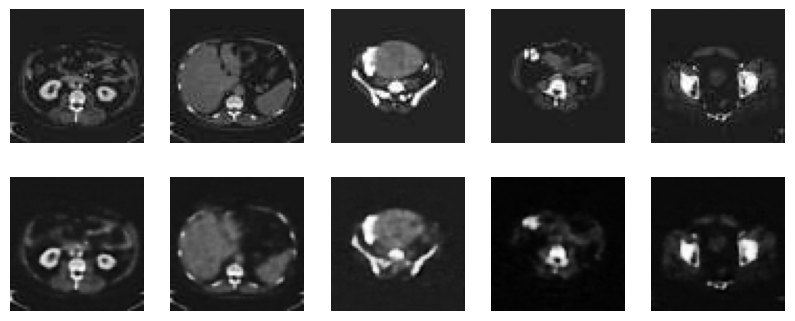

In [30]:
# Reconstruction Visualization

def show_reconstruction(model, dataset):
    for batch in dataset.take(1):
        inputs, _ = batch

        recon = model.predict(inputs)

        plt.figure(figsize=(10, 4))
        for i in range(5):
            # Original
            plt.subplot(2, 5, i+1)
            plt.imshow(inputs[i], cmap='gray')
            plt.axis('off')

            # Reconstructed
            plt.subplot(2, 5, i+6)
            plt.imshow(recon[i], cmap='gray')
            plt.axis('off')

        plt.show()

show_reconstruction(autoencoder, dataset)

# **2) Variational Autoencoder (VAE)**

In [31]:
# Build VAE Encoder

from tensorflow.keras import layers, Model

LATENT_DIM = 2   # use 2 for visualization later

# Encoder
encoder_inputs = layers.Input(shape=(64, 64, 1))

x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(encoder_inputs)
x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
x = layers.Flatten()(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)

In [32]:
# Sampling Layer

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

In [34]:
# Encoder Model

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="vae_encoder")

In [36]:
# Decoder
latent_inputs = layers.Input(shape=(LATENT_DIM,))

x = layers.Dense(16 * 16 * 64, activation='relu')(latent_inputs)
x = layers.Reshape((16, 16, 64))(x)

x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)

decoder_outputs = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

decoder = Model(latent_inputs, decoder_outputs, name="vae_decoder")

In [37]:
# VAE Class

class VAE(Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)

        # Reconstruction loss
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.keras.losses.mse(inputs, reconstructed), axis=(1,2))
        )

        # KL divergence
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        total_loss = recon_loss + kl_loss
        self.add_loss(total_loss)

        return reconstructed

In [38]:
# Train
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

history_vae = vae.fit(dataset, epochs=10)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 212ms/step - loss: 35.3193
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 216ms/step - loss: 30.4687
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 211ms/step - loss: 27.4563
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 206ms/step - loss: 26.9341
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 217ms/step - loss: 26.6119
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 208ms/step - loss: 26.3286
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 207ms/step - loss: 26.1180
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 214ms/step - loss: 25.8842
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 203ms/step - loss: 25.7002
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 217ms/step - loss: 25.5396


## **Extract Latent Representations**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━

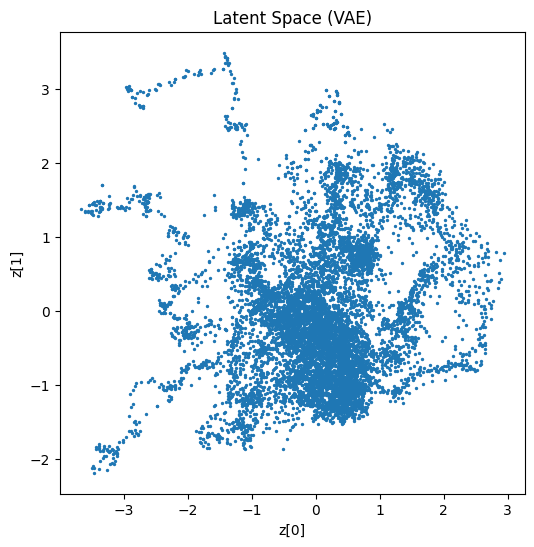

In [39]:
import matplotlib.pyplot as plt

def plot_latent_space(encoder, dataset):
    z_means = []

    for batch in dataset:
        inputs, _ = batch
        z_mean, _, _ = encoder.predict(inputs)
        z_means.append(z_mean)

    z_means = np.concatenate(z_means, axis=0)

    plt.figure(figsize=(6,6))
    plt.scatter(z_means[:, 0], z_means[:, 1], s=2)
    plt.title("Latent Space (VAE)")
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.show()

plot_latent_space(encoder, dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


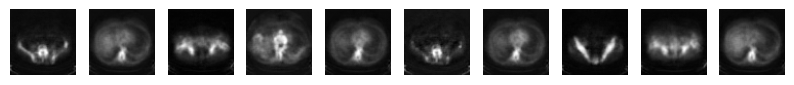

In [40]:
# Generate New Samples
def generate_images(decoder, n=10):
    z = np.random.normal(size=(n, LATENT_DIM))
    generated = decoder.predict(z)

    plt.figure(figsize=(10, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(generated[i], cmap='gray')
        plt.axis('off')
    plt.show()

generate_images(decoder, n=10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


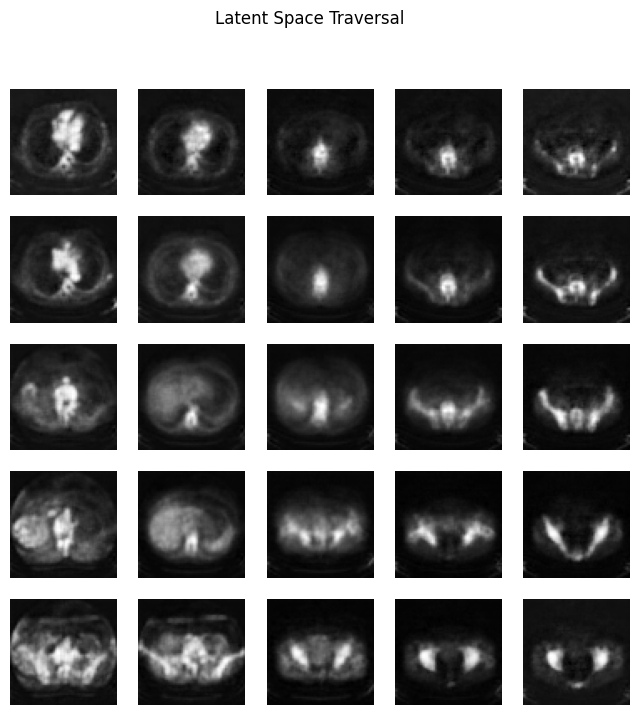

In [41]:
# Latent Space Traversal
def latent_traversal(decoder, grid_size=5):
    grid_x = np.linspace(-2, 2, grid_size)
    grid_y = np.linspace(-2, 2, grid_size)

    plt.figure(figsize=(8,8))

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = np.array([[xi, yi]])
            img = decoder.predict(z)[0]

            plt.subplot(grid_size, grid_size, i * grid_size + j + 1)
            plt.imshow(img, cmap='gray')
            plt.axis('off')

    plt.suptitle("Latent Space Traversal")
    plt.show()

latent_traversal(decoder)

# **3) AE and VAE Denoising**

In [44]:
# Add noise function
def add_noise(images, noise_factor=0.3):
    noise = tf.random.normal(shape=tf.shape(images))
    noisy_images = images + noise_factor * noise
    noisy_images = tf.clip_by_value(noisy_images, 0.0, 1.0)
    return noisy_images

In [45]:
# Create Noisy Dataset
def add_noise_pair(x, y):
    noisy_x = add_noise(x)
    return noisy_x, y   # input = noisy, target = clean

denoise_dataset = dataset.map(add_noise_pair)

## **Train Denoising AE**

In [46]:
history_denoise = autoencoder.fit(denoise_dataset, epochs=5)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 217ms/step - loss: 0.0031
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - loss: 0.0024
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 229ms/step - loss: 0.0023
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 225ms/step - loss: 0.0022
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 226ms/step - loss: 0.0021


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


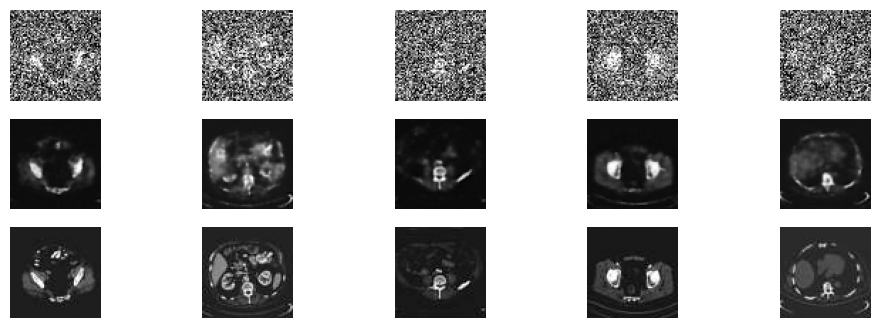

In [47]:
def show_denoising(model, dataset):
    for batch in dataset.take(1):
        noisy, clean = batch
        recon = model.predict(noisy)

        plt.figure(figsize=(12, 4))
        for i in range(5):
            # Noisy
            plt.subplot(3, 5, i+1)
            plt.imshow(noisy[i], cmap='gray')
            plt.axis('off')

            # Reconstructed
            plt.subplot(3, 5, i+6)
            plt.imshow(recon[i], cmap='gray')
            plt.axis('off')

            # Original
            plt.subplot(3, 5, i+11)
            plt.imshow(clean[i], cmap='gray')
            plt.axis('off')

        plt.show()

show_denoising(autoencoder, denoise_dataset)

# **Train on All Regions**

In [ ]:
def build_ae(latent_dim=32):
    encoder_inputs = layers.Input(shape=(64, 64, 1))
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(encoder_inputs)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim)(x)

    encoder = Model(encoder_inputs, latent)

    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(16 * 16 * 64, activation='relu')(latent_inputs)
    x = layers.Reshape((16, 16, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    outputs = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    decoder = Model(latent_inputs, outputs)

    inputs = encoder_inputs
    outputs = decoder(encoder(inputs))

    autoencoder = Model(inputs, outputs)
    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder

In [ ]:
def build_vae(latent_dim=2):

    encoder_inputs = layers.Input(shape=(64, 64, 1))
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(encoder_inputs)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)

    z_mean = layers.Dense(latent_dim)(x)
    z_log_var = layers.Dense(latent_dim)(x)

    def sampling(args):
        z_mean, z_log_var = args
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    z = layers.Lambda(sampling)([z_mean, z_log_var])

    encoder = Model(encoder_inputs, [z_mean, z_log_var, z])

    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(16 * 16 * 64, activation='relu')(latent_inputs)
    x = layers.Reshape((16, 16, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    outputs = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    decoder = Model(latent_inputs, outputs)

    class VAE(Model):
        def __init__(self, encoder, decoder):
            super().__init__()
            self.encoder = encoder
            self.decoder = decoder

        def call(self, inputs):
            z_mean, z_log_var, z = self.encoder(inputs)
            reconstructed = self.decoder(z)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.mse(inputs, reconstructed), axis=(1,2))
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )

            self.add_loss(recon_loss + kl_loss)
            return reconstructed

    vae = VAE(encoder, decoder)
    vae.compile(optimizer='adam')

    return vae

In [58]:
regions = os.listdir(extract_path)
print(regions)

['HeadCT', 'Hand', 'ChestCT', 'CXR', 'AbdomenCT', 'BreastMRI']


In [60]:
results = {}

for region in regions:
    print(f"\n🚀 Training for: {region}")

    data_dir = os.path.join(extract_path, region)

    file_list = [
        os.path.join(data_dir, f)
        for f in os.listdir(data_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if len(file_list) == 0:
        print(f"Skipping {region}")
        continue

    file_paths = tf.data.Dataset.from_tensor_slices(file_list)

    region_dataset = file_paths.map(preprocess_image)
    region_dataset = region_dataset.map(lambda x: (x, x))
    region_dataset = region_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # ---- AE ----
    ae = build_ae()   # NEW MODEL
    print("Training AE...")
    ae.fit(region_dataset, epochs=3)

    # ---- VAE ----
    vae = build_vae()  # NEW MODEL
    print("Training VAE...")
    vae.fit(region_dataset, epochs=3)

    results[region] = {
        "AE": ae,
        "VAE": vae
    }


🚀 Training for: HeadCT
Training AE...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 264ms/step - loss: 0.0344
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 250ms/step - loss: 0.0122
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 251ms/step - loss: 0.0093
Training VAE...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 244ms/step - loss: 166.2425
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 238ms/step - loss: 122.1121
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 238ms/step - loss: 108.6854

🚀 Training for: Hand
Training AE...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 248ms/step - loss: 0.0335
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 260ms/step - loss: 0.0103
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 232ms/step - loss: 0.0072
Training VAE...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 228ms/step - loss: 217.4936
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 240ms/step - loss: 130.6841
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 235ms/step - loss: 117.5772

🚀 Training for: ChestCT
Training AE...
Epoch 1/3
31

In [61]:
# Save Artifacts
SAVE_DIR = "/content/drive/MyDrive/ae_vae_results"
os.makedirs(SAVE_DIR, exist_ok=True)

for region, models in results.items():
    region_dir = os.path.join(SAVE_DIR, region)
    os.makedirs(region_dir, exist_ok=True)

    # Save weights (lighter than full models)
    models["AE"].save_weights(os.path.join(region_dir, "ae.weights.h5"))
    models["VAE"].save_weights(os.path.join(region_dir, "vae.weights.h5"))

print("Saved weights for all regions.")

Saved weights for all regions.


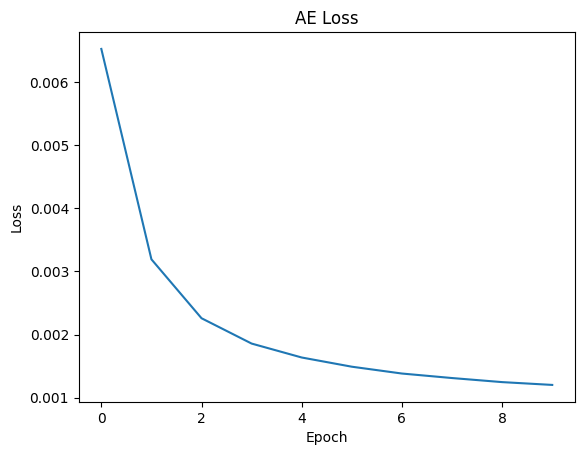

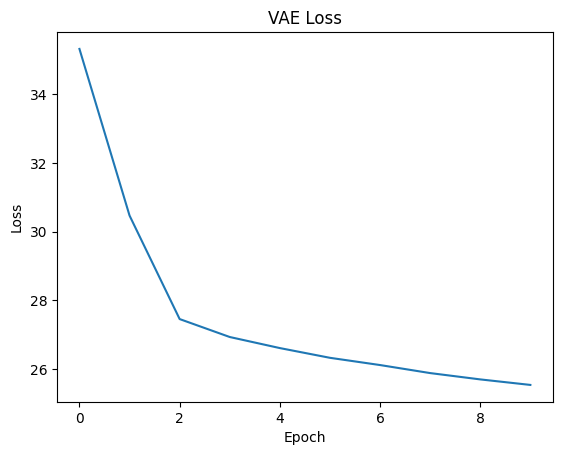

In [62]:
# Loss Visualization
def plot_loss(history, title):
    plt.plot(history.history['loss'])
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

plot_loss(history_ae, "AE Loss")
plot_loss(history_vae, "VAE Loss")